IMPORTS

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
!pip install --upgrade torch

Load Data

In [2]:
df = pd.read_csv("/content/AmesHousing.csv")

target = "SalePrice"
X = df.drop(columns=[target])
y = df[target]

Log Transform

In [3]:
y = np.log1p(y)

Drop Low-Impact Features

In [4]:
drop_cols = [
    "Mo Sold", "Yr Sold",
    "Pool Area", "Pool QC",
    "Misc Feature", "Misc Val",
    "3Ssn Porch", "Screen Porch", "Enclosed Porch",
    "Garage Qual", "Garage Cond",
    "Fence",
    "Paved Drive",
    "Sale Type",
    "Sale Condition"
]

X = X.drop(columns=drop_cols, errors="ignore")

Split Columns

In [5]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

Handle Missing Values

In [6]:
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

One-Hot Encoding

In [7]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(X[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

X = X.drop(columns=cat_cols)
X = pd.concat([X.reset_index(drop=True), encoded_df], axis=1)

Feature Scaling

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

Scale Target

In [10]:
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))

Torch Conversion

In [11]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

DataLoader

In [12]:
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=64,
    shuffle=False
)

MLP

In [13]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

Init Model

In [14]:
input_size = X_train.shape[1]
model = MLP(input_size)

criterion = nn.SmoothL1Loss()   # better than MSE
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

Training Loop

In [15]:
num_epochs = 150

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 1/150 | Train: 0.1615 | Val: 0.0752
Epoch 2/150 | Train: 0.0851 | Val: 0.0586
Epoch 3/150 | Train: 0.0802 | Val: 0.0521
Epoch 4/150 | Train: 0.0717 | Val: 0.0471
Epoch 5/150 | Train: 0.0602 | Val: 0.0480
Epoch 6/150 | Train: 0.0558 | Val: 0.0430
Epoch 7/150 | Train: 0.0545 | Val: 0.0444
Epoch 8/150 | Train: 0.0530 | Val: 0.0534
Epoch 9/150 | Train: 0.0490 | Val: 0.0451
Epoch 10/150 | Train: 0.0549 | Val: 0.0521
Epoch 11/150 | Train: 0.0510 | Val: 0.0490
Epoch 12/150 | Train: 0.0463 | Val: 0.0399
Epoch 13/150 | Train: 0.0436 | Val: 0.0411
Epoch 14/150 | Train: 0.0462 | Val: 0.0433
Epoch 15/150 | Train: 0.0486 | Val: 0.0461
Epoch 16/150 | Train: 0.0441 | Val: 0.0453
Epoch 17/150 | Train: 0.0428 | Val: 0.0465
Epoch 18/150 | Train: 0.0392 | Val: 0.0433
Epoch 19/150 | Train: 0.0418 | Val: 0.0403
Epoch 20/150 | Train: 0.0342 | Val: 0.0439
Epoch 21/150 | Train: 0.0378 | Val: 0.0431
Epoch 22/150 | Train: 0.0356 | Val: 0.0443
Epoch 23/150 | Train: 0.0340 | Val: 0.0465
Epoch 24/150 | Train

Prediction

In [16]:
model.eval()

with torch.no_grad():
    preds = model(X_test_t).numpy()

Inverse Transform

In [17]:
preds = y_scaler.inverse_transform(preds)
y_true = y_scaler.inverse_transform(y_test)

Back from Log scale

In [18]:
preds = np.expm1(preds)
y_true = np.expm1(y_true)

Final MSE

In [19]:
mse = mean_squared_error(y_true, preds)
print("Final Test MSE:", mse)

Final Test MSE: 763767075.9893743


Visualization

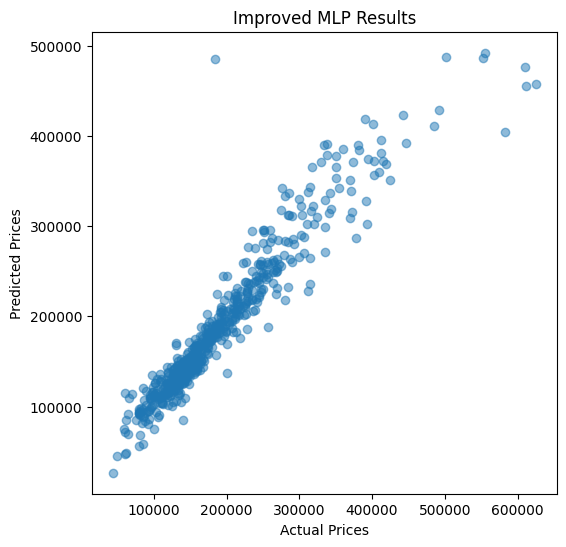

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_true, preds, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Improved MLP Results")
plt.show()